# SCIPY

SciPy, or Scientific Python, is a collection of code to perform basic scientific programming and data analysis.

Some of its contents are:
- Fourier transforms (`scipy.fft`)
- numerical integration (`scipy.integrate`)
- interpolation tools (`scipy.interpolate`)
- linear algebra routines (`scipy.linalg`)
- minimizing/maximizing objective functions, root finding, curve fitting, etc. (`scipy.optimize`)
- filtering and spectral estimation (`scipy.signal`)
- statistical functions (`scipy.stats`)

The tree of modules shown when introducing NumPy illustrates that `scipy`:
1. handles NumPy arrays
1. is the ecosystem for several scientific packages and provides a consistent interface to the functions, avoiding duplication.  The libraries `scikit-learn` – for machine learning – and `scikit-image` – for image processing – heavily rely on `scipy`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

## `scipy.integrate`

`scipy.integrate` offers several integration routines:
- `trapezoid` (the type of integration being used: $\sum_i(y_i+y_{i+1})(x_{i+1}-x_i)/2$)
- `quad` (from quadrature) 
- etc.

### `trapezoid` – integrate a function represented by a finite number of samples

By default, it assumes the $y$-values provided by the user are taken at evenly spaced values of $x$ with $\Delta x=1$, starting from $x=0$.

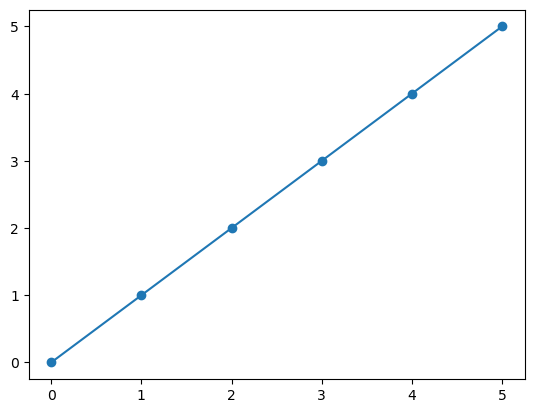

In [17]:
%matplotlib inline
#%matplotlib notebook

data = np.array([0, 1, 2, 3, 4, 5])
x = np.arange(0, len(data))
plt.plot(x, data, marker='o');

In [18]:
import scipy.integrate as integrate
result = integrate.trapezoid(data)
print(result)

12.5


[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]
 [16 17 18 19]]


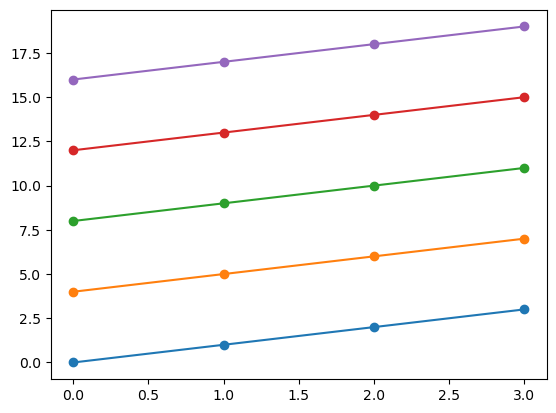

In [19]:
data = np.arange(20).reshape((5,4))
print(data)
x = np.arange(0, data.shape[1])
for i in range(data.shape[0]):
    plt.plot(x, data[i], marker='o');

In [20]:
result = integrate.trapezoid(data)
print(result)

[ 4.5 16.5 28.5 40.5 52.5]


To integrate along a different axis ("dimension") of the numpy array, use the `axis` keyword (the default is `axis=1`, as seen in the example above, so lungo le colonne integro, fissando la riga).

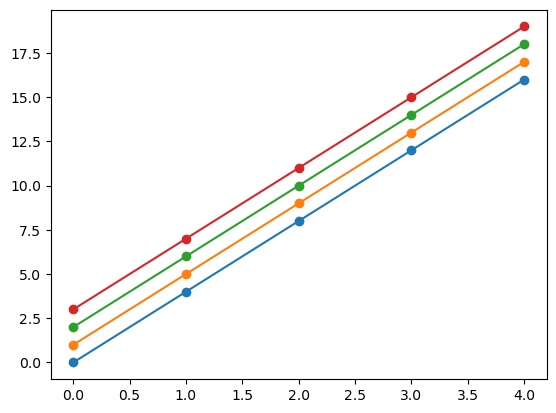

In [21]:
x = np.arange(0, data.shape[0])
for i in range(data.shape[1]):
    plt.plot(x, data[:,i], marker='o');

In [27]:
result = integrate.trapezoid(data, axis=0) #@markdown si muove integrando lungo le righe (asse =0), tenendo ferma la colonna
print(result)


12.5


You can provide a different $\Delta x$ with the keyword `dx`.

[ 0  2  4  6  8 10]


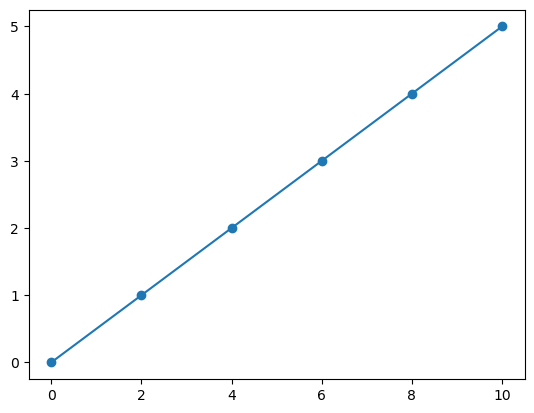

In [30]:
data = np.array([0, 1, 2, 3, 4, 5])
x = np.arange(0, 2*len(data), 2)
print(x)
plt.plot(x, data, marker='o');

In [31]:
result = integrate.trapezoid(data, dx=2)
print(result)

25.0


You can also provide specific values of $x$ with the keyword `x`, as a list for example.

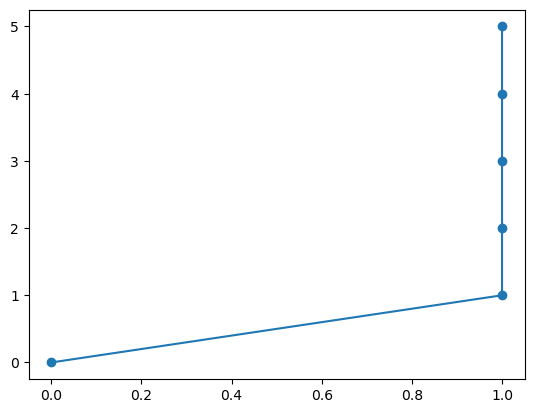

In [32]:
xnew = np.array([0,1,1,1,1,1])
plt.plot(xnew, data, marker='o');

In [33]:
result = integrate.trapezoid(data, x=xnew)
print(result)

0.5


### `quad` – integrate a function object (not data points), given the integration extremes

It returns the integral with an estimate of the error.

In [37]:
result = integrate.quad(np.sin, 0, np.pi)
print(result)

(2.0, 2.220446049250313e-14)


Consider
$$
\int_0^2 x^4\log (x+\sqrt{x^2+1}) dx\,.
$$



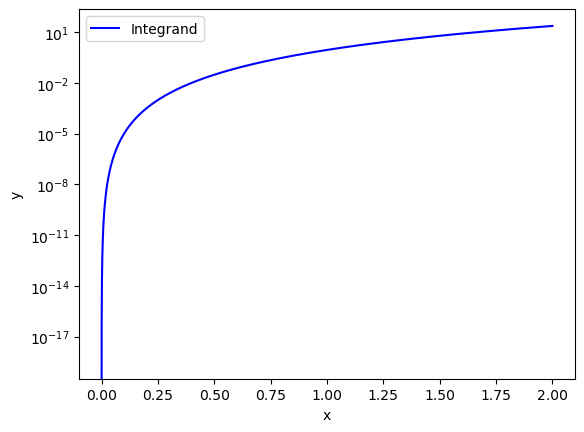

In [38]:
def integrand(x):
    return x**4*np.log(x+np.sqrt(x**2+1))

x = np.linspace(0, 2, 10000)
y = integrand(x)

plt.yscale('log')
plt.xlabel('x')
plt.ylabel('y')
plt.plot(x, y, 'b-', label='Integrand')
plt.legend();

Notice that at low $x$-values the integrand hardly varies.  The `scipy.integrate.quad()` routine is **adaptive**, i.e., it adjusts the integrand evaluations to concentrate where its variations are more significant.

In [19]:
print(integrate.quad(integrand, 0, 2))

(8.153364119811167, 9.052052573966981e-14)


### `odeint` – integrating ODEs

Many physical phenomena are modeled by differential equations: oscillations of simple systems (spring-mass, pendulum, etc.), fluid mechanics (Navier-Stokes, Laplace's, etc.), quantum mechanics (Schrödinger’s), etc.  

Here is how to numerically solve equations of this kind, in relatively simple cases...

The example looks at the 1D dynamics of a spring (with rest length $L$ and elastic constant $k$) and a mass $m$ in the presence of a drag force (with drag coefficient $\beta$).  Newton’s second law reads:
$$
{{d^2x}\over {dt^2}} + {\beta \over m}{{dx}\over {dt}} + {k\over m}(x-L) = 0\,.
$$
This is a second order differential equation that may be rewritten as a system of two first order differential equations:
$$
\begin{align}
{{dx}\over {dt}} &= v \\
{{dv}\over {dt}} &= - {\beta \over m}{v} - {k\over m}(x-L)
\end{align}
$$
to be solved in $u(t) = \{x(t), v(t)\}$.

To do this numerically we revert to `scipy.integrate.odeint`, which has the syntax
```Python
scipy.integrate.odeint(func, y0, t, args=())
```
- `func` is the **system of first order differential equations**
- `y0` is the array containing the initial values (here: $\{x_0, v_0\}$)
- `t` is the array of indipendent coordinate (here: time) values
- `args()` contains the parameters of `func` (here: $L$, $k$, $m$, and $\beta$).  The unknowns in a system of differential equations are functions: `odeint` will return the values of these functions calculated at the values provided via `t`.

In [49]:
from scipy.integrate import odeint

# Assume certain values of the physical parameters
beta = 0.4
k = 8.0
L = 0.5
m = 1.0

# Prepare func
def odes(u, t): # it is (A x)
    """This function represents the first order ODEs to be integrated
    It returns the tuple (dx/dt, dv/dt), given u=(x,v) and t."""
    x, v = u
    return (v, (-k*(x-L) - beta*v)/m)

# Prepare t, the sampling times
t = np.arange(0, 20.1, 0.00001)

# Prepare y0, i.e., the initial conditions x(t=0) and v(t=0)
u0 = np.array([1,0])

# Solve the ODEs
u = odeint(odes, u0, t)
u.shape

(2010000, 2)

[<matplotlib.lines.Line2D object at 0x7e81c4f8b710>] 1


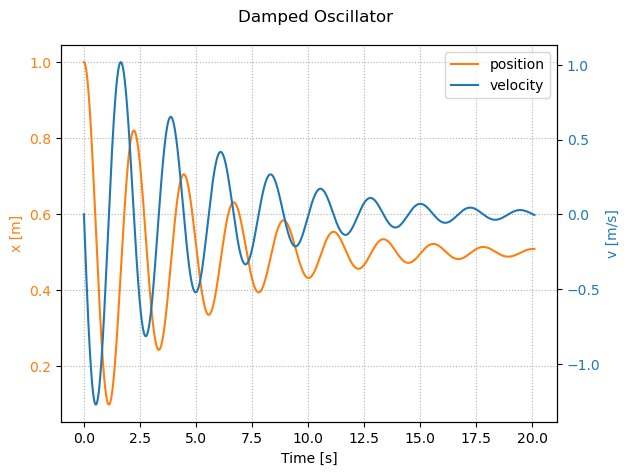

In [50]:
# Plot x and v vs t using matplotlib so that they use distinct vertical axes
x = u[:,0]
v = u[:,1]

fig, ax1 = plt.subplots()
fig.suptitle('Damped Oscillator')
ax1.set_xlabel('Time [s]')

color = 'tab:orange'
ax1.set_ylabel('x [m]', color=color)
line1 = ax1.plot(t, x, label='position', color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(ls=':')

# The second Axes object shares the x-axis with the first Axes object
ax2 = ax1.twinx()

color = 'tab:blue'
ax2.set_ylabel('v [m/s]', color=color)  # we already handled the x-label with ax1
line2 = ax2.plot(t, v, label='velocity', color=color)
ax2.tick_params(axis='y', labelcolor=color)

print(line2, len(line2))
# Legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc=0)

# Avoid clipping of the right hand side y-label
fig.tight_layout()
plt.show()

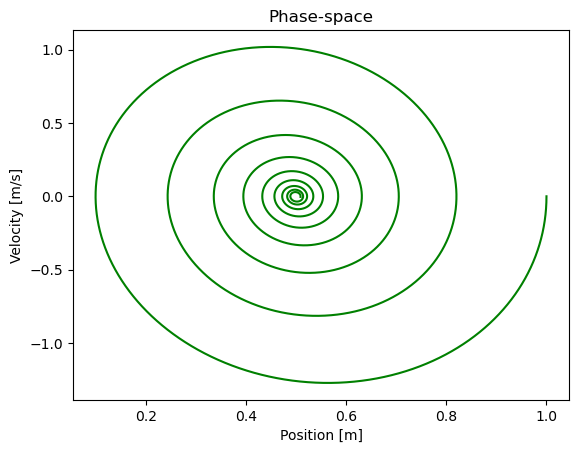

In [51]:
# Plot in phase space using matplotlib
plt.plot(x, v, color='green')
plt.title('Phase-space')
plt.xlabel('Position [m]')
plt.ylabel('Velocity [m/s]')
plt.show()

Suppose there is an obstacle in $\bar{x}$ and we want to stop the integration if the  mass hits the obstacle, i.e., at $t$ such that $x(t) = \bar{x}$, if such $t$ exists.

We revert to `scipy.integrate.solve_ivp` this time.  "IVP" stands for initial value problem. The syntax is
```Python
scipy.integrate.solve_ivp(func, t_span, y0, args=None, t_eval=None, events=None)
```
- `func` is the **system of first order differential equations**
- `t_span` is a 2-member sequence defining the integration interval 
- `y0` is the array containing the initial values (here: $\{x_0, v_0\}$)
- `args` passes the parameters of `func` (here: $L$, $k$, $m$, and $\beta$)
- `t_eval` determines specific independent variable values at which the solution must be evaluated (here: desired sampling times)
- `events` is a function, or list of functions, representing events to track; each event occurs at the zeros of a continuous function of the independent variable and state; the solver will find an accurate value of `t` at which ``event(t, y(t)) = 0`` and look for a sign change over each step.

`solve_ivp` returns a ``bunch object'' (a subclass of `dict`).
[There are other options, but we will not use them]

In [ ]:
from scipy.integrate import solve_ivp

# Time span
t_span = np.array([t[0], t[-1]])

# We modify the initial conditions, not the physical parameters of the system
u0 = np.array([0.1,0])

# t and u are inverted in the odes function
# (and we explicitly pass the parameters)
def odes(t, u, k, L, beta, m):
    x, v = u
    return (v, (-k*(x-L) - beta*v)/m)

# Define the event to stop the integration
x_bar = 0.75
def termination_condition(t, u, k, L, beta, m):  #event function: f(t, u, *arg)
    return u[0]-x_bar

# Boolean: stop the integration when this condition is met?
termination_condition.terminal = True
# Terminate when the event crosses zero from below (-1: from above)
termination_condition.direction = 1

# Solve the ODEs
# - we evaluate the solution at the same t values used with odeint
# - we pass the termination condition via events
u = solve_ivp(odes, t_span, u0, args=(k, L, beta, m),
              t_eval=t, events=termination_condition)

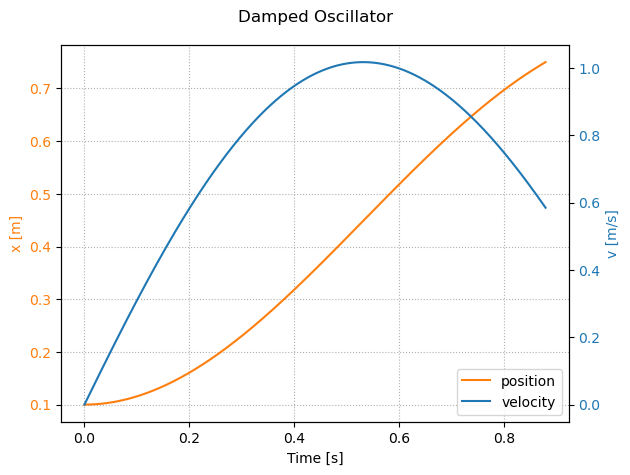

In [53]:
# Plot x and v vs t using matplotlib so that they use distinct vertical axes
x = u['y'][0]
v = u['y'][1]
t = u['t']

fig, ax1 = plt.subplots()
fig.suptitle('Damped Oscillator')
ax1.set_xlabel('Time [s]')

color = 'tab:orange'
ax1.set_ylabel('x [m]', color=color)
line1 = ax1.plot(t, x, label='position', color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(ls=':')

# The second Axes object shares the x-axis with the first Axes object
ax2 = ax1.twinx()

color = 'tab:blue'
ax2.set_ylabel('v [m/s]', color=color)  # we already handled the x-label with ax1
line2 = ax2.plot(t, v, label='velocity', color=color)
ax2.tick_params(axis='y', labelcolor=color)


# Legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc=4)

# Avoid clipping of the right hand side y-label
fig.tight_layout()
plt.show()

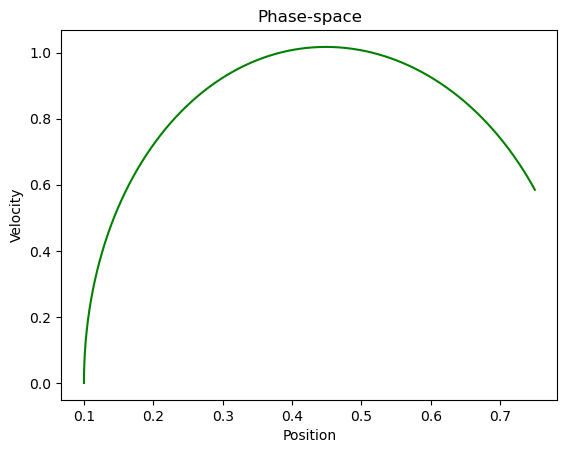

In [54]:
# Plot in phase space using matplotlib
plt.plot(x, v, color='green')
plt.title('Phase-space')
plt.xlabel('Position')
plt.ylabel('Velocity')
plt.show()

## `scipy.optimize`
### `curve_fit` – fitting data

The `scipy.optimize` package provides functions for minimizing (or maximizing) objective functions, possibly subject to constraints. It includes solvers for nonlinear problems (with support for both local and global optimization algorithms), linear programing, constrained and nonlinear least-squares, root finding, and curve fitting.

A typical science use case is to fit data to a model and estimate the model parameters.  This can be easily achieved with [`scipy.optimize.curve_fit`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html).

In this example we:

1. generate some data according to a model
1. add some random noise to the data
1. write the data to file (to refresh our memory on this task)
1. read back the data with numpy (to refresh our memory on this task)
1. fit the data with `curve_fit`

#### 1. Generate the data

In [4]:
import numpy as np

In [5]:
nevents = 100

x = np.linspace(10, 100, nevents)

def clean_data(t, A=100, tau=10):
    return A * np.exp(-t/tau)

y = clean_data(x)

[print(type(w), w.shape) for w in [x,y]];

<class 'numpy.ndarray'> (100,)
<class 'numpy.ndarray'> (100,)


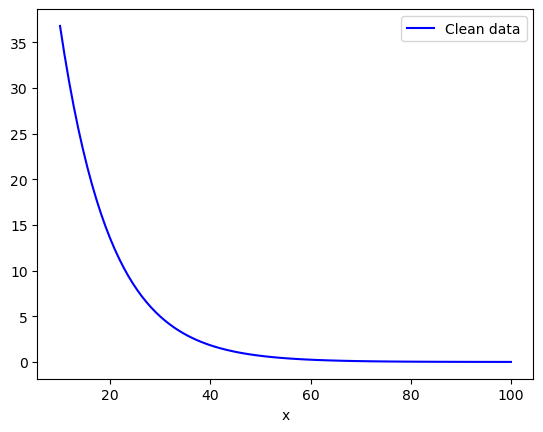

In [7]:
import matplotlib.pyplot as plt
plt.plot(x, y, 'b-', label='Clean data')
plt.xlabel('x')
plt.legend();

#### 2. Add random noise to the clean data

In [8]:
noise = 3 * np.random.normal(size=x.size)

y_noise = y + noise
import matplotlib.pyplot as plt

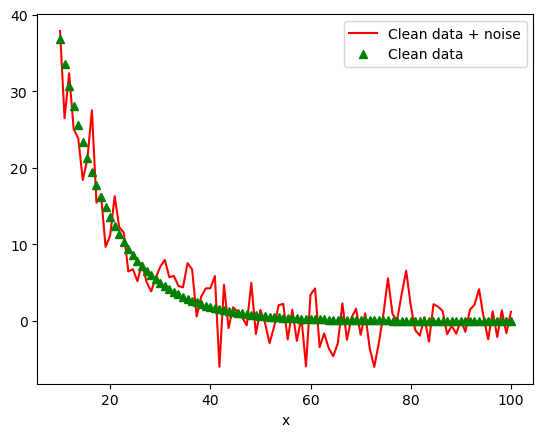

In [9]:
plt.plot(x, y_noise, 'r-', label='Clean data + noise')
plt.plot(x, y, 'g^', label='Clean data')
plt.xlabel('x')
plt.legend();

#### 3. Write the data to file

This time we use `numpy.savetxt` and loop over the arrays.

In [12]:
fname = 'data.txt'

np.savetxt(fname, (x, y, y_noise), delimiter="\t", fmt="%.5f")
!cat data.txt

10.00000	10.90909	11.81818	12.72727	13.63636	14.54545	15.45455	16.36364	17.27273	18.18182	19.09091	20.00000	20.90909	21.81818	22.72727	23.63636	24.54545	25.45455	26.36364	27.27273	28.18182	29.09091	30.00000	30.90909	31.81818	32.72727	33.63636	34.54545	35.45455	36.36364	37.27273	38.18182	39.09091	40.00000	40.90909	41.81818	42.72727	43.63636	44.54545	45.45455	46.36364	47.27273	48.18182	49.09091	50.00000	50.90909	51.81818	52.72727	53.63636	54.54545	55.45455	56.36364	57.27273	58.18182	59.09091	60.00000	60.90909	61.81818	62.72727	63.63636	64.54545	65.45455	66.36364	67.27273	68.18182	69.09091	70.00000	70.90909	71.81818	72.72727	73.63636	74.54545	75.45455	76.36364	77.27273	78.18182	79.09091	80.00000	80.90909	81.81818	82.72727	83.63636	84.54545	85.45455	86.36364	87.27273	88.18182	89.09091	90.00000	90.90909	91.81818	92.72727	93.63636	94.54545	95.45455	96.36364	97.27273	98.18182	99.09091	100.00000
36.78794	33.59110	30.67206	28.00668	25.57292	23.35065	21.32149	19.46867	17.77686	16.23206	14.82151	

#### 4. Read the data from file

In [15]:
t, z, w = np.loadtxt(fname)

[print(k.shape) for k in [t,z,w]];

(100,)
(100,)
(100,)


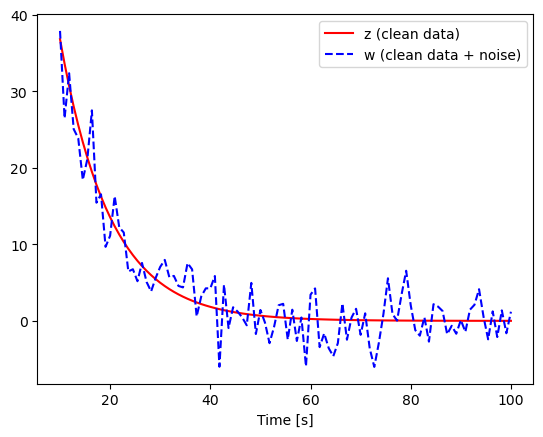

In [16]:
plt.plot(t, z, 'r-', label='z (clean data)')
plt.plot(t, w, 'b--', label='w (clean data + noise)')

plt.xlabel('Time [s]')
plt.legend();

#### 5. Fit the data

`curve_fit` takes at least three arguments:
1. the function that you want to fit;
1. a set of independent data;
1. a set of dependent data.

We will keep using NumPy arrays for the data.  One can also:

4. provide **initial guesses** for the function parameters in a keyword `p0`;

5. give relative or absolute *errors on the dependent data* using the keyword `sigma` (and `absolute_sigma`).

`curve_fit` returns the list of **optimal values** for the parameters [the values that minimize the sum of the squared residuals model($x$) - data], and their **covariance matrix**.

In [17]:
# Reminder: our clean data was generated with A * np.exp(-t/tau), with A = 100 and tau = 1/10
def fitfunc(x, N, alpha, c):
    return N*np.exp(-alpha*x) + c

param_labels = ['N', 'alpha', 'c']

In [18]:
from scipy.optimize import curve_fit

fit_pars, cov_matrix = curve_fit(fitfunc, t, w)

/tmp/ipykernel_7909/3286574463.py:3: RuntimeWarning: overflow encountered in exp
  return N*np.exp(-alpha*x) + c
/tmp/ipykernel_7909/3286574463.py:3: RuntimeWarning: overflow encountered in multiply
  return N*np.exp(-alpha*x) + c


In [21]:
print(fit_pars)

[86.36946816  0.09213548 -0.17489436]


In [20]:
print(cov_matrix)

[[8.23034470e+01 6.23193587e-02 1.35764044e+00]
 [6.23193587e-02 5.42884123e-05 1.64708285e-03]
 [1.35764044e+00 1.64708285e-03 1.60518044e-01]]


In [25]:
def print_results(fit_pars, cov_matrix, param_labels):
    [print(f"{param_labels[i]}: {fit_pars[i]:.2f} +/- {cov_matrix[i, i]**0.5:.2f}")
     for i in range(len(fit_pars))];
    [print(f"{np.abs(100*cov_matrix[i, i]**0.5/fit_pars[i]): .1f}% error on parameter {param_labels[i]}")
     for i in range(len(fit_pars))];
    
print_results(fit_pars, cov_matrix, param_labels)

N: 86.37 +/- 9.07
alpha: 0.09 +/- 0.01
c: -0.17 +/- 0.40
 10.5% error on parameter N
 8.0% error on parameter alpha
 229.1% error on parameter c


In [28]:
fit_pars_with_guess, cov_matrix_with_guess = curve_fit(fitfunc, t, w, p0=[100., 0.1, 0.])

In [29]:
print_results(fit_pars_with_guess, cov_matrix_with_guess, param_labels)

N: 86.37 +/- 9.07
alpha: 0.09 +/- 0.01
c: -0.17 +/- 0.40
 10.5% error on parameter N
 8.0% error on parameter alpha
 229.1% error on parameter c


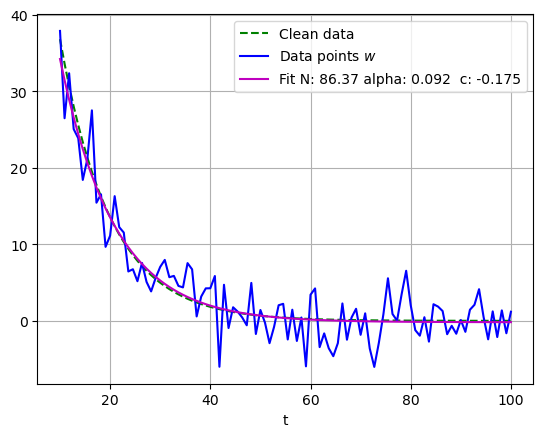

In [30]:
plt.plot(x, y, 'g--', label='Clean data')

plt.plot(t, w, 'b-', label='Data points $w$')

plt.plot(t, fitfunc(t, *fit_pars), 'm-',
         label=f'Fit N: {fit_pars[0]:.2f} alpha: {fit_pars[1]:.3f}  c: {fit_pars[2]:.3f}')

plt.legend()
plt.xlabel('t')
plt.grid()

In [31]:
#Clean up
!rm data.txt

## `scipy.fft`

Fourier analysis is a method for expressing a function as a sum of periodic components, and for recovering the signal from those components. When both the function and its Fourier transform are replaced with discretized counterparts, it is referred to as discrete Fourier transform (DFT). The DFT has become a mainstay of numerical computing in part because of the Fast Fourier Transform (FFT), a very fast algorithm to compute it.

The DFT $y[k]$ of length $N$ of the length-$N$ sequence $x[n]$ is defined as
$$
\begin{align}
y[k] = \sum_{n=0}^{N-1} x[n]\exp\left(\frac{-2\pi jk n}{N}\right)
\end{align}
$$
and the inverse transform is defined as follows
$$
\begin{align}
x[n] = \sum_{k=0}^{N-1} y[k]\exp\left(\frac{2\pi jk n}{N}\right)\,.
\end{align}
$$
These may be computed with the methods `fft` and `ifft` ("i" stands for inverse).

In [1]:
import scipy.fft
x = np.array([1.0, -1.0, 1.0, -1.0, 1.0, -1.0])

y = scipy.fft.fft(x)
print(y)

yinv = scipy.fft.ifft(y)
print(yinv)

NameError: name 'np' is not defined

Note that by definition
$$
\begin{align}
y[0] = \sum_{n=0}^{N-1} x[n]\,.
\end{align}
$$

This mathematical condition lends itself to a consistency test with the built-in construct `assert`.

In [41]:
assert y[0] == x.sum(), "Your FFT is bugged!"

AssertionError: Your FFT is bugged!

In [45]:
assert y[0] != x.sum(), "Perhaps this test is nonsense!"

For even values of $N$, $y[1], \ldots, y[N/2-1]$ contain the positive-frequency terms, while the elements $y[N/2], \ldots, y[N-1]$ contain the **negative-frequency, so negative k,** terms, in order of decreasingly negative frequency.

For odd values $N$, $y[1], \ldots, y[(N-1)/2-1]$ contain the positive-frequency terms, while the elements $y[(N+1)/2], \ldots, y[N-1]$ contain the negative-frequency terms, in order of decreasingly negative frequency.

If $x\in\mathbb{R}~~\forall n$, the values of the FFT for positive frequencies are the conjugate of the values for negative frequencies (because the spectrum is symmetric). Typically, only the FFT corresponding to positive frequencies is plotted.

(25,)


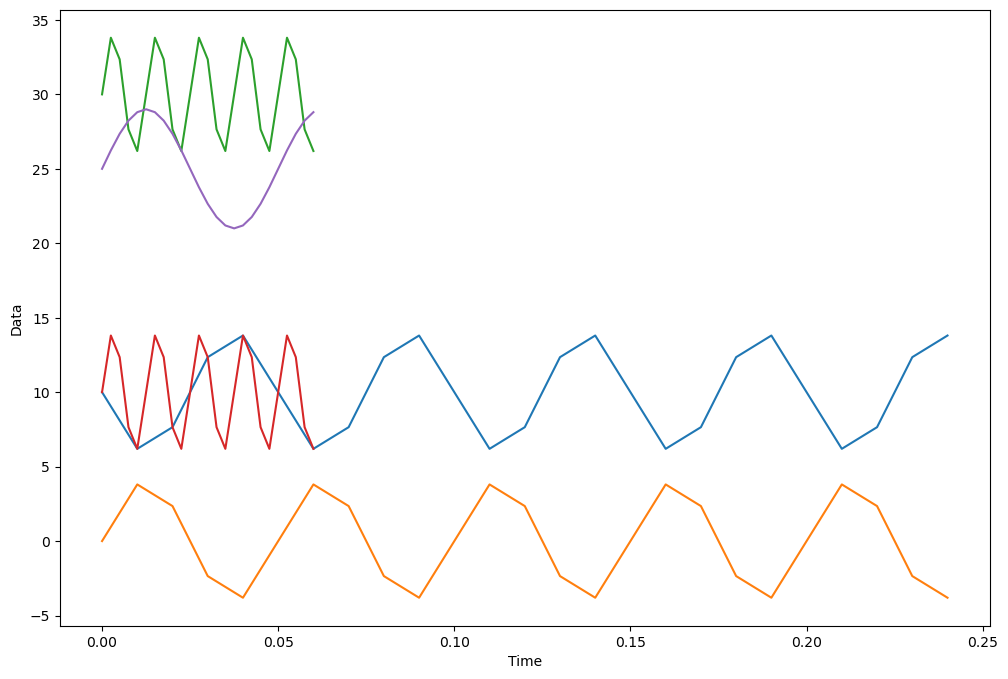

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
# Number of sample points
N = 25
# sample spacing
#800 is the frequency sampling
#400 will be the nyquist frequency  maximum admitted to avoid aliasing phenomena
T = 1.0 / 100.0
# The time vector
x = np.linspace(0.0, N*T, N, endpoint=False, )
# The sampled values
# y = np.sin(50.0 * 2.0*np.pi*x) + 0.5*np.sin(80.0 * 2.0*np.pi*x)
y =  4*np.sin(80.0 * 2.0*np.pi*x)+ +10

y2 =  4*np.sin(20 * 2.0*np.pi*x)+ +0

x2=  np.linspace(0.0, N* (T/4), N, endpoint=False, )
y3 =  4*np.sin(80.0 * 2.0*np.pi*x2)+ +30

y4 =  4*np.sin(20 * 2.0*np.pi*x2)+ +25


plt.figure(figsize=(12, 8))
plt.xlabel('Time')

plt.ylabel('Data')
plt.plot(x, y)
plt.plot(x, y2)
plt.plot(x2, y3)
plt.plot(x2, y3-20)
plt.plot(x2, y4)

print(x.shape)

The `fftfreq` method returns the FFT Fourier domain independent variable points.

In [78]:
-N/2  / (T *N)

-50.0

0.25
-48.0


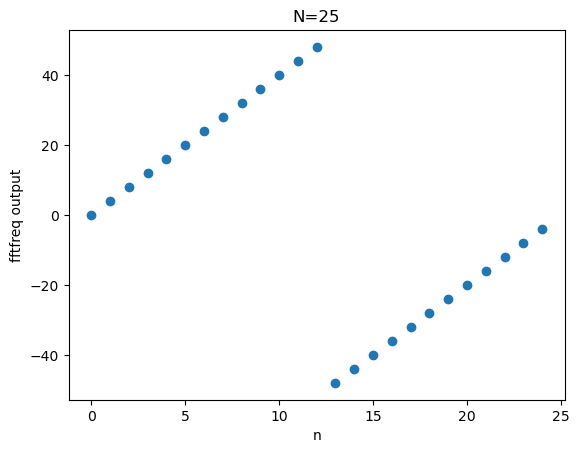

In [ ]:
plt.scatter(range(N), scipy.fft.fftfreq(N,  T), ) #frequencies but PER UNIT OF SAMPLING TIME es second!!
# Given a window length n and a sample spacing d:

print(T*N)
#   f = [0, 1, ...,   n/2-1,     -n/2, ..., -1] / (d*n)   if n is even, d=1 if not set 
#   f = [0, 1, ..., (n-1)/2, -(n-1)/2, ..., -1] / (d*n)   if n is odd
print(min(scipy.fft.fftfreq(N,  T)))
# spacing is d=T

plt.xlabel('n');
plt.ylabel('fftfreq output')
plt.title(f'N={N}');

We are dealing with real-valued data and only look at the right-hand-side of the spectrum.

(250-0j) 250.00000000000003


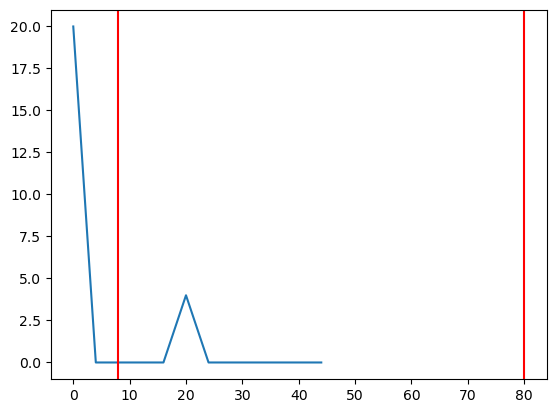

In [79]:
yf = scipy.fft.fft(y)
xf = scipy.fft.fftfreq(N)[:N//2] /T #if d=1,  to have the correct range: I need to normalize by d_true=T

plt.plot(xf, 2.0/N * np.abs(yf[:N//2]))
plt.axvline(8, color='red')
plt.axvline(80, color='red')

print(yf[0], y.sum())
assert round(np.abs(yf[0]))==round(np.abs(y.sum())), "FFT bug"

The FFT input signal is inherently truncated. This truncation can be modeled as the multiplication of an infinite signal with a rectangular window function. In the spectral domain, this multiplication becomes the convolution of the signal spectrum with the window function spectrum being of form $\sin(x)/x$. This convolution is the cause of an effect called spectral leakage (Gibbs phenomenon). 

Here is the discontinuity at the start of our data series.

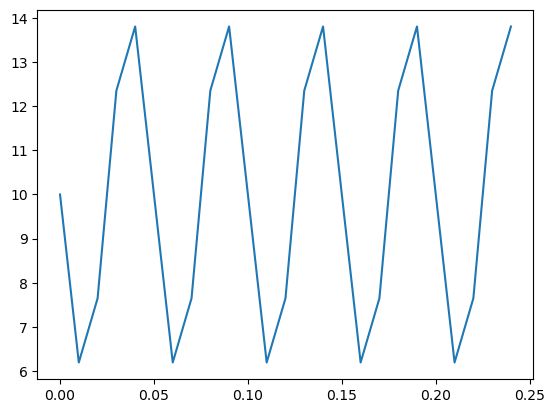

In [80]:
plt.plot(x, y)
# plt.xlim(0,0.01);

Let's window our function prior to FFT-ing it: this will smoothen the onset of the data, at the end of the data.  Windowing functions are available in `scipy.signal`, under `windows`.

Windowing the signal with a dedicated window function helps mitigate spectral leakage, as shown in the examples below.

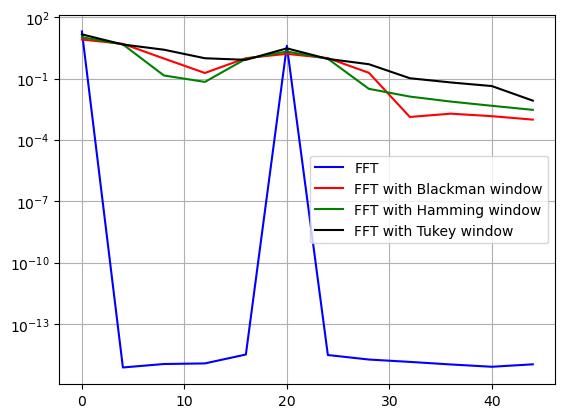

In [81]:
w = scipy.signal.windows.blackman(N)
ywbf = scipy.fft.fft(y*w)

w = scipy.signal.windows.hamming(N)
ywhf = scipy.fft.fft(y*w)

w = scipy.signal.windows.tukey(N)
ywtf = scipy.fft.fft(y*w)

plt.semilogy(xf[:N//2], 2.0/N * np.abs(yf[:N//2]), '-b', label='FFT')
plt.semilogy(xf[:N//2], 2.0/N * np.abs(ywbf[:N//2]), '-r', label='FFT with Blackman window')
plt.semilogy(xf[:N//2], 2.0/N * np.abs(ywhf[:N//2]), '-g', label='FFT with Hamming window')
plt.semilogy(xf[:N//2], 2.0/N * np.abs(ywtf[:N//2]), '-k', label='FFT with Tukey window')
plt.legend()
plt.grid()
plt.show()

If $x$ is complex-valued, the spectrum is no longer symmetric. To simplify working with the FFTs, `scipy` provides the method `fftshift` which allows swapping the lower and upper halves of a vector, so that it becomes suitable for plotting purposes. `scipy` then uses this function internally to handle the complex case.

In [74]:
x = np.arange(8)
scipy.fft.fftshift(x)

array([4, 5, 6, 7, 0, 1, 2, 3])

We will not be diving deeper into this use case in this course.

## `scipy.stats`
### Drawing from distributions

We will use a different package (Seaborn) to make our plots, as a reminder of the many options Python offers to do things.

In [91]:
import seaborn as sns
# settings for seaborn plotting style
sns.set(color_codes=True)
# settings for seaborn plot sizes
sns.set(rc={'figure.figsize':(3,3)})

#### 1. Uniform distribution

In [87]:
from scipy.stats import uniform

In [88]:
nevents = 10000
start = 10
width = 20
# rvs stands for random variable sample(s)
data = uniform.rvs(size=nevents, loc=start, scale=width)

In [89]:
print(data)

[26.63957531 15.19406688 27.3750043  ... 20.6387033  29.55974797
 14.56653121]


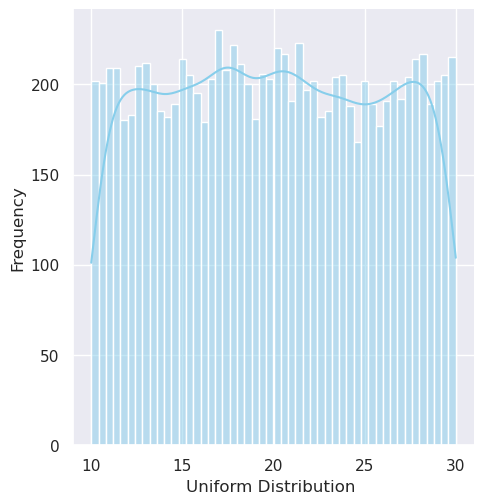

In [92]:
ax = sns.displot(data, bins=50, kde=True,
                 color='skyblue', linewidth=1, alpha=0.5)
ax.set(xlabel='Uniform Distribution ', ylabel='Frequency');

#### 2. Normal distribution

In [93]:
from scipy.stats import norm

In [96]:
nevents = 10000
# rvs stands for random variates
data = norm.rvs(size=nevents, loc=0, scale=1)
print(data.shape)

(10000,)


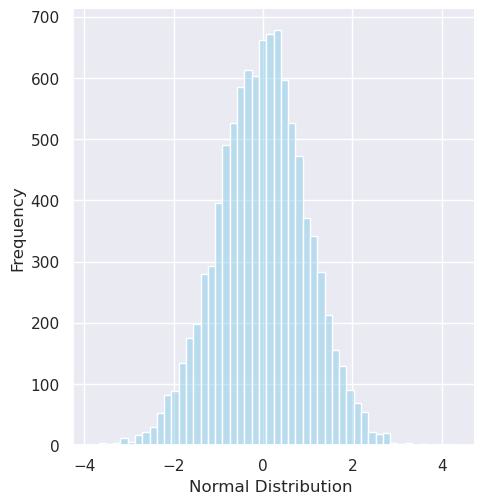

In [ ]:
ax = sns.displot(data, bins=50, kde=True,
                 color='skyblue', linewidth=1, alpha=0.5)
ax.set(xlabel='Normal Distribution ', ylabel='Frequency');

#### 3. Exponential distribution

In [98]:
from scipy.stats import expon

In [99]:
nevents = 10000
# rvs stands for random variates
data = expon.rvs(size=nevents, loc=0, scale=1)

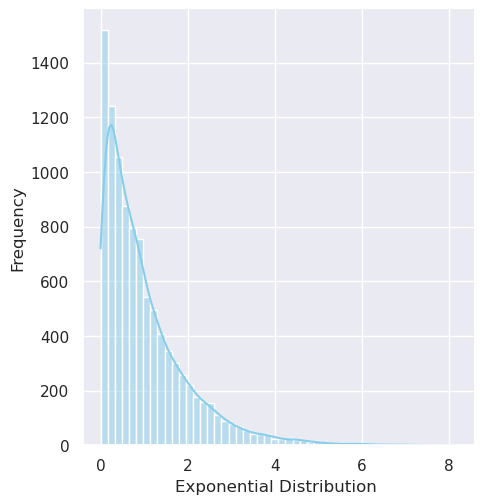

In [100]:
ax = sns.displot(data, bins=50, kde=True,
                  color='skyblue', linewidth=1, alpha=0.5)
ax.set(xlabel='Exponential Distribution ', ylabel='Frequency');